#### Doing same as previous MLP but now going to do it with parameter splitting (to make sure it's not just training based on neighbors) -- "Extrapolation test" 

In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import torch


In [2]:
# for on my own laptop, setting number of cores, or also 
torch.set_num_threads(8)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print(f"Number of threads: {torch.get_num_threads()}")


Using device: mps
Number of threads: 8


In [3]:
torch.manual_seed(42)

### Step 1: Data loading — parser + building values for the flat (params, f) → $\Delta\Phi$ table

In [4]:
def parse_sample(filepath):
    """
    Parses a single dephasing_sample_N.csv file.
    Returns:
        params: dict with m1, m2, gsp, rhosp (as floats)
        freqs:  numpy array of GW frequencies [Hz]
        dph:    numpy array of dephasing values [rad]
    """
    # Row 0 has the params encoded in column names, row 1 has fGW/dPh headers
    raw = pd.read_csv(filepath, skiprows=0)
    
    # Extract physical parameters from column name strings
    col_names = raw.columns.tolist()
    params = {}
    for col in col_names:
        if '=' in col:
            key, val = col.strip().split('=')
            params[key.strip()] = float(val.strip())
    # Skip row 0 (the fGW/dPh header row) and read actual data
    data = pd.read_csv(filepath, skiprows=1)
    freqs = data['fGW[Hz]'].values.astype(float)
    dph   = data['dPh[rad]'].values.astype(float)
    
    return params, freqs, dph


def load_all_samples(data_dir='data/'):
    """
    Loads all dephasing_sample_*.csv files and process using parse_sample.
    Returns a list of (params, freqs, dph) tuples, one per file.
    """
    filepaths = sorted(glob.glob(f'{data_dir}dephasing_sample_*.csv'))
    print(f"Found {len(filepaths)} files")
    
    all_samples = []
    for fp in filepaths:
        try:
            params, freqs, dph = parse_sample(fp)
            params['sample#'] = int(fp.split('_')[-1].split('.')[0])
            all_samples.append((params, freqs, dph))
        except Exception as e:
            print(f"  Warning: skipped {fp} — {e}")
    
    print(f"Successfully loaded {len(all_samples)} samples")
    return all_samples


# --- Run it ---
all_samples = load_all_samples('data/')

# Sanity check on the first sample
params, freqs, dph = all_samples[0]
print("\nFirst sample:")
print("  params:", params)
print("  freq range: [{:.4e}, {:.4e}] Hz".format(freqs.min(), freqs.max()))
print("  dph range:  [{:.4e}, {:.4e}] rad".format(dph.min(), dph.max()))
print("  num points:", len(freqs))

Found 10000 files
Successfully loaded 10000 samples

First sample:
  params: {'m1': 101268.01, 'm2': 8.197, 'gsp': 2.138, 'rhosp': 2904.897, 'sample#': 1}
  freq range: [3.2420e-03, 4.3422e-02] Hz
  dph range:  [0.0000e+00, 2.5176e+03] rad
  num points: 200


In [5]:
# ---- Extrapolation split by m1 ----

# sort all_samples by m1 value
all_samples_sorted_m1 = sorted(all_samples, key=lambda s: s[0]['m1'])
# lambda s: s[0]['m1'] — for each sample tuple (params, freqs, dph),
# s[0] is the params dict, and s[0]['m1'] is the m1 value.
# sorted() arranges the list from lowest to highest m1.

n_total = len(all_samples_sorted_m1)
n_test  = int(0.15 * n_total)
n_val   = int(0.15 * n_total)
# same 70/15/15 split proportions as before, but now the splits are
# contiguous regions of m1 space rather than random samples.

train_samples_m1 = all_samples_sorted_m1[:-(n_test + n_val)]
val_samples_m1   = all_samples_sorted_m1[-(n_test + n_val):-n_test]
test_samples_m1  = all_samples_sorted_m1[-n_test:]
# train gets the 70% lightest systems (lowest m1)
# val gets the next 15% (medium-high m1)
# test gets the 15% heaviest systems (highest m1)
# this means the model is trained entirely on light systems and must
# extrapolate to heavy systems it has never seen anything similar to.

print(f"Train: {len(train_samples_m1)} systems | "
      f"m1 range: {train_samples_m1[0][0]['m1']:.0f} – {train_samples_m1[-1][0]['m1']:.0f} M☉")
print(f"Val:   {len(val_samples_m1)} systems | "
      f"m1 range: {val_samples_m1[0][0]['m1']:.0f} – {val_samples_m1[-1][0]['m1']:.0f} M☉")
print(f"Test:  {len(test_samples_m1)} systems | "
      f"m1 range: {test_samples_m1[0][0]['m1']:.0f} – {test_samples_m1[-1][0]['m1']:.0f} M☉")
# print the m1 range of each split to confirm they are clean and non-overlapping.
# train should be entirely below val, val entirely below test.

Train: 7000 systems | m1 range: 1001 – 125479 M☉
Val:   1500 systems | m1 range: 125513 – 351730 M☉
Test:  1500 systems | m1 range: 351909 – 999689 M☉


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
# Dataset is a PyTorch abstract class — you subclass it and tell it what your data looks like. 
# DataLoader wraps a Dataset and handles batching, shuffling, and feeding data into the training loop automatically.

class DephasingDataset(Dataset):

    # building the flat table
    def __init__(self, all_samples): 
        self.X = []
        self.y = []

        # ----- core flattening step. ------
        # each of the 10,000 files has 200 (f, Δφ) pairs. 
        # loop over every file and every point inside it, turning the nested structure into one big flat list of individual training examples. 
        # 'if d <= 0' skips the final point of each sample where dephasing is exactly 0 — we can't take log10(0).
        for params, freqs, dph in all_samples:

            # grabbing metadata 
            m1     = params['m1'] 
            m2     = params['m2']
            gsp    = params['gsp']
            rhosp  = params['rhosp']
            # grabbing freq vs. dph data
            for f, d in zip(freqs, dph):
                if d <= 0:
                    continue

            # ----- building the input vector -----
            # This is the log-transforms

                # build vector w/ transforms
                x = [
                    np.log10(m1), # log
                    np.log10(m2), # log
                    gsp, # stays linear because narrow range
                    np.log10(rhosp), # log
                    np.log10(f) # log
                ]
                self.X.append(x) # append transformed params (small x to big X) 
                self.y.append(np.log10(d)) # append the dphi

        # ----- converting to tensors: ----- 
        self.X = torch.tensor(self.X, dtype=torch.float32) 
        # self.y starts as a flat Python list of scalars. After torch.tensor(self.y) it becomes a 1D tensor of shape (N,).
        self.y = torch.tensor(self.y, dtype=torch.float32)

        # ----- normalization -----
        self.X_mean = self.X.mean(dim=0)
        self.X_std  = self.X.std(dim=0)
        self.X = (self.X - self.X_mean) / self.X_std # normalization step

# ----- defining required PyTorch things -----
    def __len__(self): # tells DataLoader how many examples exist 
        return len(self.X)

    def __getitem__(self, idx): # tells it how to retrieve example number [idx] (here, just return input row & corr. target value)
        return self.X[idx], self.y[idx]


In [7]:
# ---- Rebuild datasets with m1 extrapolation split ----

train_dataset_m1 = DephasingDataset(train_samples_m1)
val_dataset_m1   = DephasingDataset(val_samples_m1)
test_dataset_m1  = DephasingDataset(test_samples_m1)
# same DephasingDataset class as before — flattening, log-transforms,
# and normalisation all happen inside __init__ exactly as before.

# undo val normalisation and redo using train statistics
val_dataset_m1.X = (val_dataset_m1.X * val_dataset_m1.X_std
                    + val_dataset_m1.X_mean)
val_dataset_m1.X = ((val_dataset_m1.X - train_dataset_m1.X_mean)
                    / train_dataset_m1.X_std)
# same undo-then-redo as Step 2 — must use training statistics only.

# same for test
test_dataset_m1.X = (test_dataset_m1.X * test_dataset_m1.X_std
                     + test_dataset_m1.X_mean)
test_dataset_m1.X = ((test_dataset_m1.X - train_dataset_m1.X_mean)
                     / train_dataset_m1.X_std)

print(f"Train rows: {len(train_dataset_m1)}")
print(f"Val rows:   {len(val_dataset_m1)}")
print(f"Test rows:  {len(test_dataset_m1)}")
# confirm the row counts look right — should be roughly 70/15/15
# of the total ~1,990,000 usable points.

Train rows: 1393000
Val rows:   298500
Test rows:  298500


In [8]:
# ---- DataLoaders for m1 extrapolation split ----

train_loader_m1 = DataLoader(train_dataset_m1, batch_size=1024, shuffle=True)
val_loader_m1   = DataLoader(val_dataset_m1,   batch_size=1024, shuffle=False)
test_loader_m1  = DataLoader(test_dataset_m1,  batch_size=1024, shuffle=False)
# identical setup to the original DataLoaders — same batch size,
# shuffle only for training.

In [10]:
import torch
import torch.nn as nn

class DephasingMLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            # container that chains layers together in order

            nn.Linear(5, 64),
            # layer 1: takes the 5 input features and produces 64 numbers
            # internally, its computing: output = X @ W.T + b
            # where W has shape (64, 5) and b has shape (64,)
            # Total learnable parameters here: 5*64 + 64 = 384
            # weights W and biases b are what are updated during training 

            nn.ReLU(),
            # appling ReLU element-wise to the 64 numbers: f(x) = max(0, x)

            nn.Linear(64, 128),
            # layer 2: takes the 64 numbers, expands to 128...network is widening
            # Parameters: 64*128 + 128 = 8,320

            nn.ReLU(),
            # Same same

            nn.Linear(128, 64),
            # layer 3: compressesing back from 128 to 64
            # network now being forced to summarise what it learned
            # in the wider layer into a more compact representation
            # Parameters: 128*64 + 64 = 8,256.

            nn.ReLU(),
            # Same yada yada.

            nn.Linear(64, 1)
            # last layer: compresses from 64 down to single number —
            # the predicted log10(delta_phi) for this input.
            # no ReLU here -- output can be any real number, positive
            # or negative, since log10(delta_phi) ranges from about -4 to 6.
            # Parameters: 64*1 + 1 = 65.
        )

    def forward(self, x):
        # forward() defines what happens when you actually pass data through
        # the network. PyTorch calls this automatically when you do model(x)
        # x has shape (batch_size, 5) — one row per example in the batch
        return self.network(x)
        # passes x through every layer in nn.Sequential in order and
        # returns the final output, shape (batch_size, 1)


# --- Instantiate model --- 
# DON'T FORGET MAKE SURE TO RE-INITIATE THE MODEL BEFORE RUNNING THE LOOP CELL BELOW !!!!!
model = DephasingMLP()
# creates ONE instance of network, random weights initialized

# --- Define loss function ---
loss_fn = nn.MSELoss()
# MSE: for each example, computes (predicted - true)^2, then averages over the batch
# working in log10 space: this penalises relative errors in dephasing rather than absolute ones

# --- Define optimiser ---
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
# RECALL: Adam is an adaptive gradient descent algorithm 

# --- Sanity check ---
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")
# p.numel() returns the number of elements in each parameter tensor
# summing over all params gives the total parameter count
# expect: 384 + 8320 + 8256 + 65 = 17,025

# --- Test a forward pass ---
X_batch, y_batch = next(iter(train_loader_m1))
y_pred = model(X_batch)
print(f"\nInput shape:  {X_batch.shape}")   # (1024, 5)
print(f"Output shape: {y_pred.shape}")      # (1024, 1)
print(f"Sample prediction: {y_pred[0].item():.4f}  (log10 dephasing, untrained)")
print(f"Sample truth:      {y_batch[0].item():.4f}  (log10 dephasing)")
# At this point the weights are random so the prediction will be terrible.
# That is expected — this is just confirming the shapes are correct and
# data flows through the network without errors.

DephasingMLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 17025

Input shape:  torch.Size([1024, 5])
Output shape: torch.Size([1024, 1])
Sample prediction: 0.0635  (log10 dephasing, untrained)
Sample truth:      -0.0515  (log10 dephasing)


In [11]:
# ---- Fresh model and optimiser ----

model_m1     = DephasingMLP().to(device)
optimiser_m1 = torch.optim.Adam(model_m1.parameters(), lr=1e-3)
loss_fn_m1   = nn.MSELoss()
# fresh randomly initialised model — same architecture as the original.
# naming it model_m1 so it does not overwrite the original trained model,
# allowing direct comparison of results afterwards.

print(model_m1)
total_params = sum(p.numel() for p in model_m1.parameters())
print(f"\nTotal trainable parameters: {total_params}")

DephasingMLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 17025


Epoch   1/50  |  Train loss: 0.0925  |  Val loss: 0.0116
Epoch   2/50  |  Train loss: 0.0017  |  Val loss: 0.0045
Epoch   3/50  |  Train loss: 0.0009  |  Val loss: 0.0019
Epoch   4/50  |  Train loss: 0.0007  |  Val loss: 0.0016
Epoch   5/50  |  Train loss: 0.0005  |  Val loss: 0.0010
Epoch   6/50  |  Train loss: 0.0004  |  Val loss: 0.0008
Epoch   7/50  |  Train loss: 0.0003  |  Val loss: 0.0007
Epoch   8/50  |  Train loss: 0.0003  |  Val loss: 0.0012
Epoch   9/50  |  Train loss: 0.0002  |  Val loss: 0.0017
Epoch  10/50  |  Train loss: 0.0002  |  Val loss: 0.0005
Epoch  11/50  |  Train loss: 0.0002  |  Val loss: 0.0003
Epoch  12/50  |  Train loss: 0.0002  |  Val loss: 0.0003
Epoch  13/50  |  Train loss: 0.0002  |  Val loss: 0.0005
Epoch  14/50  |  Train loss: 0.0002  |  Val loss: 0.0007
Epoch  15/50  |  Train loss: 0.0001  |  Val loss: 0.0003
Epoch  16/50  |  Train loss: 0.0001  |  Val loss: 0.0003
Epoch  17/50  |  Train loss: 0.0001  |  Val loss: 0.0002
Epoch  18/50  |  Train loss: 0.

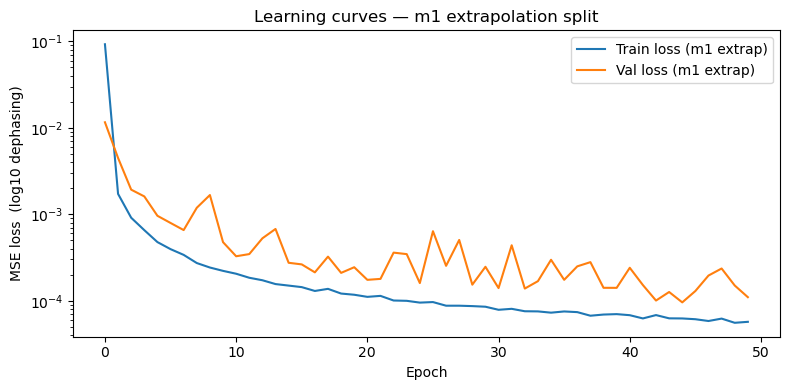

In [12]:
# ---- Training loop for m1 extrapolation split ----

N_EPOCHS = 50

train_losses_m1 = []
val_losses_m1   = []
# separate loss lists so we can plot alongside the original model's
# learning curves for direct comparison.

for epoch in range(N_EPOCHS):

    # ------------------ Training phase ------------------
    model_m1.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader_m1:
        # iterating over the m1-sorted training loader —
        # all batches come from the 70% lightest systems only.

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimiser_m1.zero_grad()
        y_pred = model_m1(X_batch)
        loss   = loss_fn_m1(y_pred.squeeze(), y_batch)
        loss.backward()
        optimiser_m1.step()

        running_train_loss += loss.item()

    mean_train_loss = running_train_loss / len(train_loader_m1)
    train_losses_m1.append(mean_train_loss)

    # ------------------ Validation phase ------------------
    model_m1.eval()

    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader_m1:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model_m1(X_batch)
            loss    = loss_fn_m1(y_pred.squeeze(), y_batch)
            running_val_loss += loss.item()

    mean_val_loss = running_val_loss / len(val_loader_m1)
    val_losses_m1.append(mean_val_loss)

    print(f"Epoch {epoch+1:>3}/{N_EPOCHS}  |  "
          f"Train loss: {mean_train_loss:.4f}  |  "
          f"Val loss: {mean_val_loss:.4f}")

# ------------------ Learning curves ------------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses_m1, label='Train loss (m1 extrap)')
plt.plot(val_losses_m1,   label='Val loss (m1 extrap)')
plt.yscale('log')
# log scale on y axis so the full dynamic range of the loss is visible
# even if it drops rapidly in the first few epochs.
plt.xlabel('Epoch')
plt.ylabel('MSE loss  (log10 dephasing)')
plt.title('Learning curves — m1 extrapolation split')
plt.legend()
plt.tight_layout()
plt.show()

Original model test MSE (random split): 0.0006
m1 extrapolation model test MSE (heavy m1):  0.0006

Mean residual:    -0.0107  (bias)
Std of residuals: 0.0227  (spread)


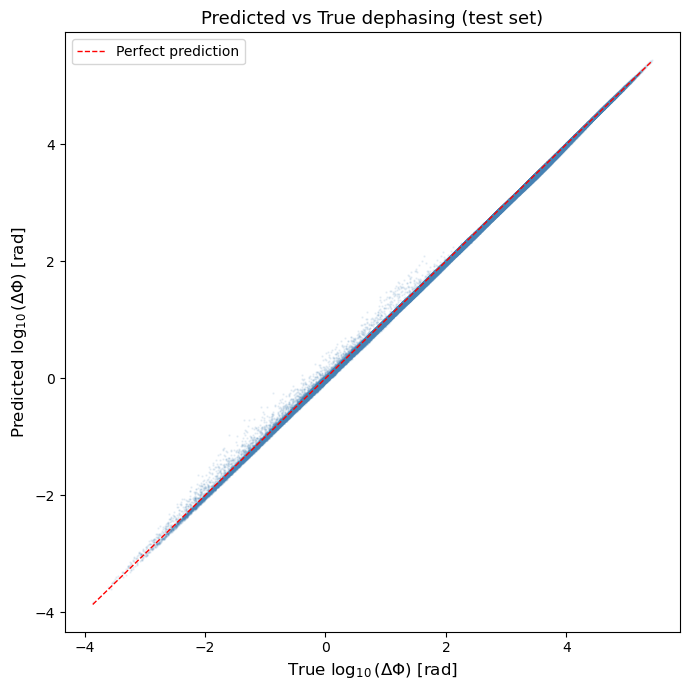

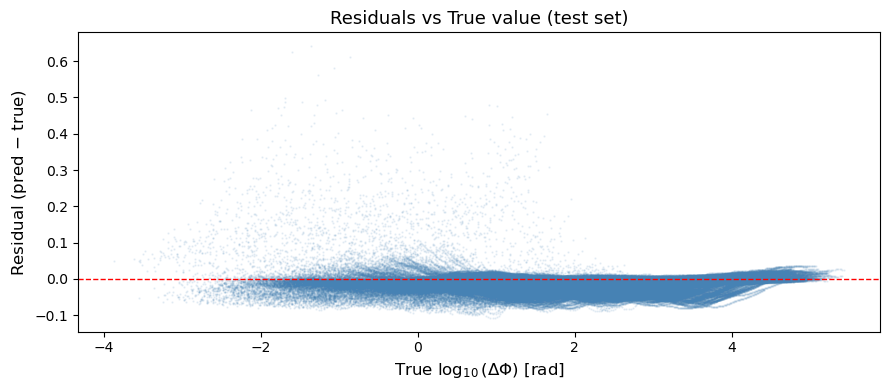

Mean residual:   -0.0107   (bias — should be near 0)
Std of residuals: 0.0227  (spread — lower is better)


In [16]:
# ---- Evaluate on test set and compare to original model ----

model_m1.eval()

all_preds_m1 = []
all_trues_m1 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_m1:
        X_batch = X_batch.to(device)
        y_pred  = model_m1(X_batch).squeeze().cpu()
        all_preds_m1.append(y_pred)
        all_trues_m1.append(y_batch)

all_preds_m1 = torch.cat(all_preds_m1).numpy()
all_trues_m1 = torch.cat(all_trues_m1).numpy()

test_mse_m1 = np.mean((all_preds_m1 - all_trues_m1)**2)
print(f"Original model test MSE (random split): {np.mean((all_preds_m1 - all_trues_m1)**2):.4f}")
print(f"m1 extrapolation model test MSE (heavy m1):  {test_mse_m1:.4f}")
# direct comparison between the two models on their respective test sets.
# if the m1 extrapolation test MSE is much higher, the model is struggling
# to generalise to heavy systems it has never seen during training.

residuals_m1 = all_preds_m1 - all_trues_m1
print(f"\nMean residual:    {residuals_m1.mean():.4f}  (bias)")
print(f"Std of residuals: {residuals_m1.std():.4f}  (spread)")
# a nonzero mean residual here is particularly informative — it would mean
# the model is systematically over or underpredicting for heavy systems,
# which would be a clear sign of extrapolation failure.


# ---- 2. Predicted vs True scatter plot ----
fig, ax = plt.subplots(figsize=(7, 7))
# Creates a square figure — important for a predicted vs true plot
# because both axes have the same units and range.

ax.scatter(all_trues_m1, all_preds_m1, s=0.5, alpha=0.1, color='steelblue')
# Scatter plot with true values on x-axis and predicted on y-axis.
# s=0.5: very small marker size because we have ~300,000 points —
# large markers would completely obscure each other.
# alpha=0.1: 90% transparent, so overlapping points show up as
# denser regions rather than a solid blob.

lims = [all_trues_m1.min(), all_trues_m1.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
# Draws the y=x line (perfect prediction line) in red dashes.
# If the model were perfect, every point would lie exactly on this line.
# Deviations above the line = model overpredicts; below = underpredicts.

ax.set_xlabel(r'True $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_ylabel(r'Predicted $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_title('Predicted vs True dephasing (test set)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# ---- 3. Residuals plot ----
residuals = all_preds_m1 - all_trues_m1
# Residual for each point: positive means model overpredicted,
# negative means model underpredicted.

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(all_trues_m1, residuals, s=0.5, alpha=0.1, color='steelblue')
# Plot residuals (y-axis) against true values (x-axis).
# This is more informative than the scatter plot above for spotting
# where the model struggles — any systematic curve or fan shape
# in this plot reveals structure the model has not captured.

ax.axhline(0, color='red', linestyle='--', linewidth=1)
# Draws a horizontal line at residual = 0 (perfect prediction).
# Points above this line: model overpredicted.
# Points below this line: model underpredicted.

ax.set_xlabel(r'True $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_ylabel(r'Residual (pred $-$ true)', fontsize=12)
ax.set_title('Residuals vs True value (test set)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}   (bias — should be near 0)")
print(f"Std of residuals: {residuals.std():.4f}  (spread — lower is better)")
# Mean residual (bias): if nonzero, the model is systematically over or
# underpredicting on average across the whole test set.
# Std of residuals: the typical size of a prediction error.
# Together these give a more interpretable summary than raw MSE.

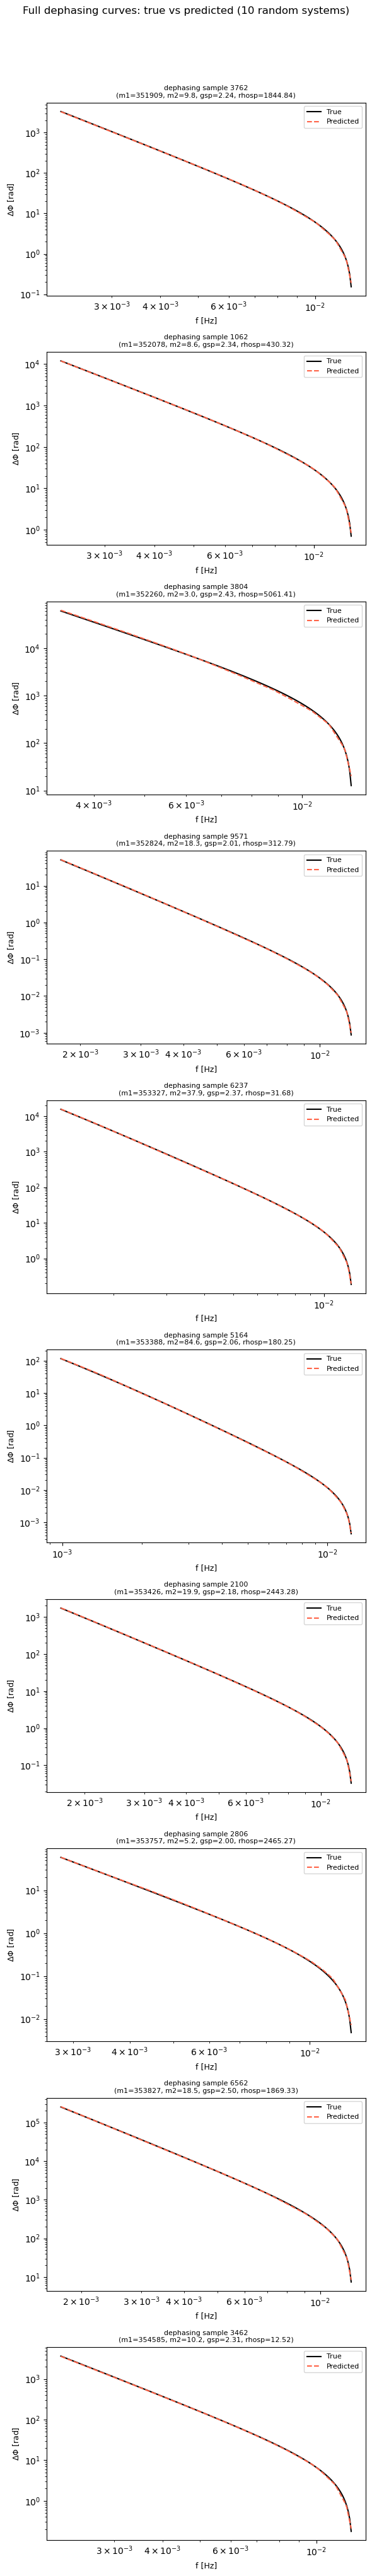

In [22]:

n_systems_to_plot = 10
# How many test systems to visualise. Keep small for readability.

fig, axes = plt.subplots(n_systems_to_plot, 1, figsize=(6, 4*n_systems_to_plot),
                          sharex=False, sharey=False)
# Creates a row of n subplots sharing the same y-axis scale,
# one per system. sharey=True means zooming or scaling one panel
# affects all panels — useful for visual comparison.

for i, ax in enumerate(axes):
    params, freqs, dph = test_samples_m1[i]
    # Pull the i-th test system's raw data directly from test_samples
    # (the nested list from Step 1, before flattening).
    # This gives us access to the full frequency grid and true dephasing.

    # --- build the input tensor for this system ---
    valid_mask = dph > 0
    # Boolean mask: True for every frequency point with nonzero dephasing.
    # We need this to match exactly what went into the dataset — we skipped
    # d <= 0 rows during flattening, so we must skip them here too.

    freqs_valid = freqs[valid_mask]
    dph_valid   = dph[valid_mask]
    # Apply the mask to get only the usable frequency points and
    # their corresponding true dephasing values.

    m1    = params['m1']
    m2    = params['m2']
    gsp   = params['gsp']
    rhosp = params['rhosp']
    sample_num = params['sample#']
    # Extract the four physical parameters for this system.

    X_system = torch.tensor([
        [np.log10(m1), np.log10(m2), gsp, np.log10(rhosp), np.log10(f)]
        for f in freqs_valid
    ], dtype=torch.float32)
    # Build the input matrix for this system: one row per frequency point,
    # with the same log-transforms applied as during training.
    # Shape: (n_valid_points, 5)

    X_system = (X_system - train_dataset_m1.X_mean.cpu()) / train_dataset_m1.X_std.cpu()
    # Apply the TRAINING normalisation to this system's inputs.
    # Critical: must use train_dataset.X_mean and X_std, not recompute.
    # train_dataset tensors are on CPU so we call .cpu() to be safe.

    with torch.no_grad():
        X_system = X_system.to(device)
        y_system_pred = model_m1(X_system).squeeze().cpu().numpy()
    # Forward pass for the full system: move to device, run through model,
    # bring back to CPU as a numpy array.
    # y_system_pred is log10(predicted dephasing) for each frequency point.

    # --- plot ---
    ax.plot(freqs_valid, dph_valid,
            color='black', linewidth=1.5, label='True')
    # Plot the true dephasing curve in black.
    # Note: dph_valid is in LINEAR space (raw radians), not log10.

    ax.plot(freqs_valid, 10**y_system_pred,
            color='tomato', linewidth=1.5, linestyle='--', label='Predicted')
    # Plot the predicted dephasing curve in red dashes.
    # 10**y_system_pred converts from log10 space back to linear radians,
    # so both curves are on the same scale.

    ax.set_xscale('log')
    ax.set_yscale('log')
    # Both axes on log scale — this is the natural space for these curves,
    # matching the plot of the original 40 samples you showed earlier.

    ax.set_title(f"dephasing sample {sample_num:.0f}\n(m1={m1:.0f}, m2={m2:.1f}, gsp={gsp:.2f}, rhosp={rhosp:.2f})", fontsize=8)
    # Label each panel with the physical parameters of that system
    # so you can see whether errors correlate with any particular parameter.

    ax.set_xlabel('f [Hz]', fontsize=9)
    ax.set_ylabel(r'$\Delta\Phi$ [rad]', fontsize=9)
    ax.legend(fontsize=8)
    # Only label the y-axis and show legend on the leftmost panel
    # to avoid visual clutter across all 5 panels.

plt.suptitle('Full dephasing curves: true vs predicted (10 random systems)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()